# Training phase

## Setting up the configuration
Fisrt let's check the configuration parameters in case you want to change some of them base on the previous analysis. In any case the default configuration should **provide you with a good start**.


In [5]:
import os
from pathlib import Path
from planktonclass import config, paths

def find_project_config(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [start, start.parent]
    for root in candidates:
        conf_path = root / 'config.yaml'
        if conf_path.exists():
            return conf_path
    for root in [start, *start.parents]:
        conf_path = root / 'config.yaml'
        if conf_path.exists():
            return conf_path
    raise FileNotFoundError('Could not find config.yaml in the current project. Start Jupyter in the project root or its notebooks folder.')

CONF_PATH = find_project_config()
PROJECT_DIR = CONF_PATH.parent
config.set_config_path(str(CONF_PATH))
paths.CONF = config.get_conf_dict()
print(f"Using project config: {os.path.relpath(CONF_PATH, Path.cwd())}")

config.print_conf_table()


Using project config: ..\config.yaml
group                    key                           value                         
augmentation             train_mode                    None            

augmentation             use_augmentation              False           

augmentation             val_mode                      None            

---------------------------------------------------------------------------

dataset                  mean_RGB                      None            

dataset                  split_ratios                  [0.8, 0.1, 0.1] 

dataset                  std_RGB                       None            

---------------------------------------------------------------------------

general                  base_directory                .               

general                  images_directory              ./data/images   

---------------------------------------------------------------------------

model                    image_size                    100    

In case you want to change the configuration feel free to do so by modifying a project-local `config.yaml` generated by `planktonclass init`, or by adapting the packaged template in `planktonclass/resources/config.yaml`.

## Training

Once you have set up the configuration if needed you can launch the training by running the file `train_runfile.py`


In [6]:
from datetime import datetime
from planktonclass import config
from planktonclass.train_runfile import train_fn

CONF = config.get_conf_dict()
CONF['dataset']['num_workers'] = 1
TIMESTAMP = datetime.now().strftime('%Y-%m-%d_%H%M%S')
print(f'Starting training run: {TIMESTAMP}')
train_fn(TIMESTAMP=TIMESTAMP, CONF=CONF)
print(f'Training finished. Use TIMESTAMP = {TIMESTAMP} in the downstream notebooks if you want to inspect this run.')


2026-03-31 18:41:10 - planktonclass.utils - INFO - [utils] Created 8 dataset directories
2026-03-31 18:41:10 - planktonclass.train_runfile - INFO - [train] Writing run log to: ../models/2026-03-31_184110/logs/training.log
2026-03-31 18:41:10 - planktonclass.train_runfile - INFO - [train] Using existing dataset splits
2026-03-31 18:41:10 - planktonclass.train_runfile - INFO - [train] Loading training data
2026-03-31 18:41:10 - planktonclass.train_runfile - INFO - [train] Splits directory: ../models/2026-03-31_184110/dataset_files
2026-03-31 18:41:10 - planktonclass.train_runfile - INFO - [train] Images directory: ../data/images
2026-03-31 18:41:10 - planktonclass.data_utils - INFO - [data] Loading train split
2026-03-31 18:41:10 - planktonclass.data_utils - INFO - [data] Loading val split
2026-03-31 18:41:10 - planktonclass.data_utils - INFO - [data] Loading class names
2026-03-31 18:41:10 - planktonclass.data_utils - INFO - [data] Loading aphia IDs
2026-03-31 18:41:10 - planktonclass.t

Starting training run: 2026-03-31_184110
2026-03-31 18:41:10 - planktonclass.data_utils - INFO - [data] Computing RGB statistics: 100%|██████████| 82/82 [00:00<00:00, 737.41img/s]

2026-03-31 18:41:10 - planktonclass.data_utils - INFO - [data] Mean RGB pixel: [142.34101527548236, 142.34101527548236, 142.34101527548236]
2026-03-31 18:41:10 - planktonclass.data_utils - INFO - [data] RGB standard deviation: [45.52169288103683, 45.52169288103683, 45.52169288103683]
2026-03-31 18:41:10 - planktonclass.train_runfile - INFO - [train] Building model


2026-03-31 18:41:11 - planktonclass.train_runfile - INFO - [train] Starting training
2026-03-31 18:41:11 - planktonclass.train_runfile - INFO - [train] Epochs: 15 | Batch size: 16 | Training samples: 82 | Validation samples: 15
2026-03-31 18:41:11 - planktonclass.utils - INFO - [train] Epoch metrics will be written to training.log and epoch_metrics.csv.


2026-03-31 18:41:11 - planktonclass.train_runfile - INFO - [train] Best model will be saved to: ../models/2026-03-31_184110/ckpts/best_model.keras
2026-03-31 18:41:11 - planktonclass.train_runfile - INFO - [train] Epoch 1/15
2026-03-31 18:42:01 - planktonclass.train_runfile - INFO - [train] 6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.2873 - loss: 1.6232
2026-03-31 18:42:04 - planktonclass.train_runfile - INFO - [train] Epoch 1: val_accuracy improved from None to 0.20000, saving model to ../models/2026-03-31_184110/ckpts/best_model.keras

2026-03-31 18:42:05 - planktonclass.train_runfile - INFO - [train] Epoch 1: finished saving model to ../models/2026-03-31_184110/ckpts/best_model.keras
2026-03-31 18:42:05 - planktonclass.train_runfile - INFO - [train] 6/6 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.3902 - loss: 1.4956 - val_accuracy: 0.2000 - val_loss: 1.9932 - lr: 0.0010 - learning_rate: 0.0010
2026-03-31 18:42:05 - planktonclass.train_runfile - INFO - [train] Epoch 2/15


...

2026-03-31 18:42:28 - planktonclass.train_runfile - INFO - [train] Epoch 14/15
2026-03-31 18:42:29 - planktonclass.train_runfile - INFO - [train] 6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9549 - loss: 0.1362
2026-03-31 18:42:29 - planktonclass.train_runfile - INFO - [train] Epoch 14: val_accuracy improved from 0.40000 to 0.60000, saving model to ../models/2026-03-31_184110/ckpts/best_model.keras

2026-03-31 18:42:31 - planktonclass.train_runfile - INFO - [train] Epoch 14: finished saving model to ../models/2026-03-31_184110/ckpts/best_model.keras
2026-03-31 18:42:31 - planktonclass.train_runfile - INFO - [train] 6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 556ms/step - accuracy: 0.9512 - loss: 0.1234 - val_accuracy: 0.6000 - val_loss: 0.9769 - lr: 1.0000e-05 - learning_rate: 1.0000e-05
2026-03-31 18:42:31 - planktonclass.train_runfile - INFO - [train] Epoch 15/15
2026-03-31 18:42:32 - planktonclass.train_runfile - INFO - [train] 6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9559 - los

2026-03-31 18:42:34 - planktonclass.train_runfile - INFO - [train] Training complete
2026-03-31 18:42:34 - planktonclass.train_runfile - INFO - [train] Saving to: ../models/2026-03-31_184110
2026-03-31 18:42:34 - planktonclass.train_runfile - INFO - [train] Saving training statistics
2026-03-31 18:42:34 - planktonclass.train_runfile - INFO - [train] Saving final model
2026-03-31 18:42:35 - planktonclass.train_runfile - INFO - [train] Saving configuration
2026-03-31 18:42:35 - planktonclass.train_runfile - INFO - [train] Default testing checkpoint: best_model.keras
2026-03-31 18:42:35 - planktonclass.train_runfile - INFO - [train] Training finished successfully.
2026-03-31 18:42:35 - planktonclass.train_runfile - INFO - [train] Evaluating test split
2026-03-31 18:42:35 - planktonclass.train_runfile - INFO - [train] Reloading preferred checkpoint for test evaluation: ../models/2026-03-31_184110/ckpts/best_model.keras
2026-03-31 18:42:37 - planktonclass.data_utils - INFO - [data] Loading 

2026-03-31 18:42:39 - planktonclass.train_runfile - INFO - [train] 8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


2026-03-31 18:42:39 - planktonclass.train_runfile - INFO - [train] Predictions saved to: ../models/2026-03-31_184110/predictions/best_model.keras+DS_split+top5.json
2026-03-31 18:42:39 - planktonclass.train_runfile - INFO - [train] Test metrics saved to: ../models/2026-03-31_184110/predictions/best_model.keras+DS_split+metrics.json
2026-03-31 18:42:39 - planktonclass.train_runfile - INFO - [train] Test set evaluation completed.


Training finished. Use TIMESTAMP = 2026-03-31_184110 in the downstream notebooks if you want to inspect this run.


#### Tips: 
* Running a python file is also done by 
    1. opening a terminal 
    2. typing: `planktonclass train --config ./my_project/config.yaml` or running the training cell in this notebook from the copied project folder
* If you are running several times different training configurations but with the **same** dataset you might consider to add the `mean_RGB` and `std_RGB` parameters to your `config.yaml` file. You can find them computed in any of your already trained models by looking into `../models/[timestamp]/conf/conf.txt`.

## Visualizing the training results

### Display a single timestamp

Total training time: 1 day, 1:45:46


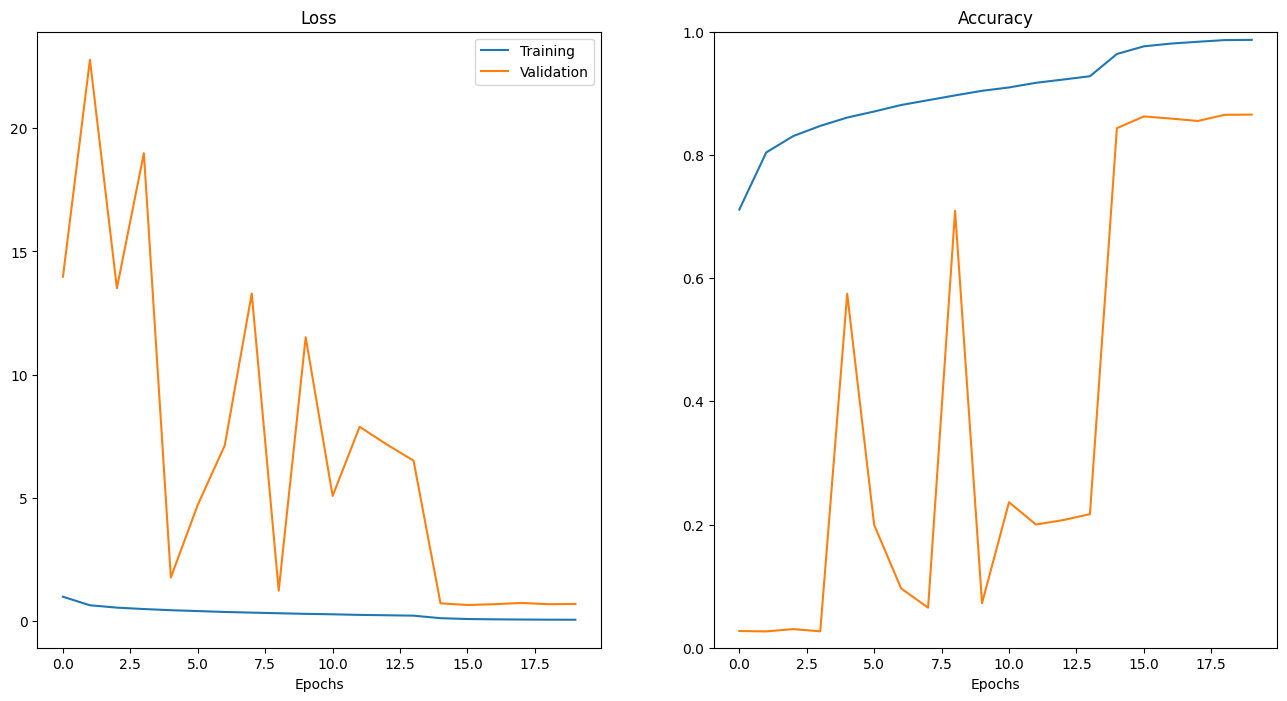

In [7]:
import os
import json
from datetime import timedelta

import matplotlib.pylab as plt
import numpy as np

from planktonclass import paths, plot_utils
from datetime import datetime

timestamp = datetime.now().strftime('%Y-%m-%d_%H:%M:%S')
TIMESTAMP = timestamp
# User parameters to set
TIMESTAMP = 'FlowCam'                       # timestamp of the pretrained model

# Set the timestamp
paths.timestamp = TIMESTAMP

# Load training statistics
stats_path = os.path.join(paths.get_stats_dir(), 'stats.json')
with open(stats_path) as f:
    stats = json.load(f)

# Load training configuration
conf_path = os.path.join(paths.get_conf_dir(), 'conf.json')
with open(conf_path) as f:
    conf = json.load(f)

# Plot the trainig plots 
plot_utils.training_plots(conf, stats)

# Print total training time
tr_time = int(stats['training time (s)'])
print('Total training time: {}'.format(timedelta(seconds=tr_time)))

### Compare between multiple timestamps

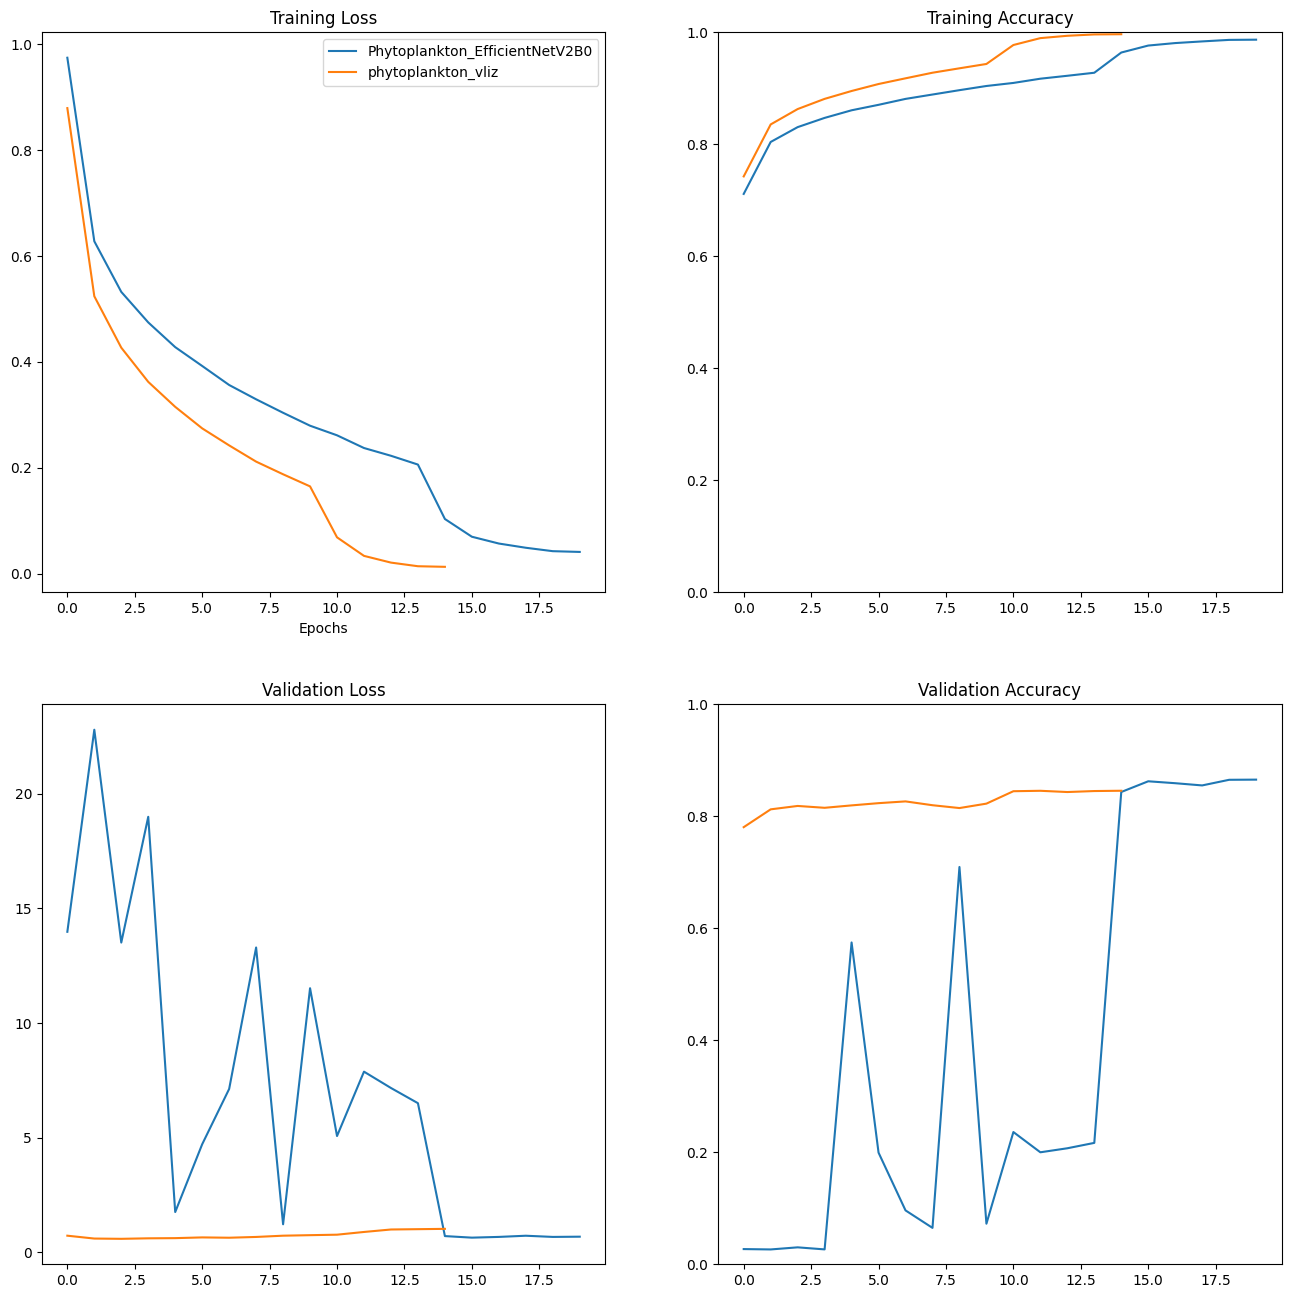

In [8]:
from planktonclass.plot_utils import multi_training_plots

TIMESTAMPS = ['FlowCam',
              'phytoplankton_vliz']

multi_training_plots(timestamps=TIMESTAMPS)